Loading training data...
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Loading test data...
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Training data shape: (3000, 28, 28)
Training labels shape: (3000,)
Test data shape: (17000, 28, 28)

After preprocessing:
x_train shape: (3000, 28, 28, 1)
y_train shape: (3000, 10)


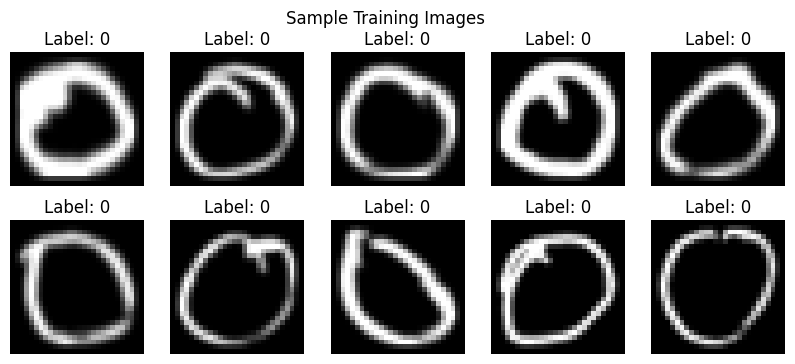

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

# === WHY THESE IMPORTS? ===
# PIL: Reads image files
# NumPy: Converts images to number arrays
# TensorFlow/Keras: Builds and trains the neural network
# Matplotlib: Displays images to verify correctness

# Define paths - CHANGE THESE TO YOUR ACTUAL PATHS!
train_dir = "/content/drive/MyDrive/AI/Test"   # Folder with training images
test_dir = "/content/drive/MyDrive/AI/Train"     # Folder with test images
img_height, img_width = 28, 28  # All images resized to 28x28 pixels

def load_images_from_folder(folder):
    """
    Reads all images from subfolders and returns:
    - images: NumPy array of image data
    - labels: NumPy array of corresponding labels (0-9)
    """
    images = []
    labels = []

    # Get sorted class names (digit_0, digit_0, ...) and filter out non-directories
    # The `.DS_Store` file is often created by macOS and is not a directory.
    class_names = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])
    print(f"Found classes: {class_names}")

    # Create mapping: "digit_0" -> 0, "digit_1" -> 1, etc.
    # WHY? Folder names are text, but neural network needs numbers
    class_map = {name: i for i, name in enumerate(class_names)}
    print(f"Class mapping: {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # ---- STEP 1: Load image ----
            # "L" converts to grayscale (removes color, keeps brightness)
            img = Image.open(img_path).convert("L")

            # ---- STEP 2: Resize to consistent size ----
            # Neural networks need all inputs to have the same shape
            img = img.resize((img_width, img_height))

            # ---- STEP 3: Convert to NumPy array ----
            img_array = np.array(img)

            # ---- STEP 4: Normalize (0-255 → 0-1) ----
            # WHY? Neural networks learn better when numbers are small (0-1)
            # Pixel values are originally 0 (black) to 255 (white)
            normalized_img = img_array / 255.0

            images.append(normalized_img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load the data
print("Loading training data...")
x_train_raw, y_train_raw = load_images_from_folder(train_dir)

print("Loading test data...")
x_test_raw, y_test_raw = load_images_from_folder(test_dir)

# Check what we loaded
print(f"\nTraining data shape: {x_train_raw.shape}")
print(f"Training labels shape: {y_train_raw.shape}")
print(f"Test data shape: {x_test_raw.shape}")

# ---- STEP 5: Reshape for Keras ----
# Keras expects shape: (num_samples, height, width, channels)
# channels=1 because grayscale (RGB would be 3)
x_train = x_train_raw.reshape(-1, img_height, img_width, 1)
x_test = x_test_raw.reshape(-1, img_height, img_width, 1)

# ---- STEP 6: One-hot encode labels ----
# WHY? Softmax output produces probabilities for each class
# One-hot encoding means: digit 3 becomes [0,0,0,1,0,0,0,0,0,0]
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print(f"\nAfter preprocessing:")
print(f"x_train shape: {x_train.shape}")  # (num_images, 28, 28, 1)
print(f"y_train shape: {y_train.shape}")  # (num_images, 10)

# ---- STEP 7: Verify by displaying sample images ----
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.show()

In [2]:
from tensorflow.keras import layers, models

# ---- WHY SEQUENTIAL? ----
# Sequential is like a pipeline: data flows through layers in order
# Input → Layer1 → Layer2 → Layer3 → Output

model = models.Sequential([
    # ---- INPUT LAYER ----
    # Specifies the shape of each image (28x28 grayscale)
    layers.Input(shape=(28, 28, 1)),

    # ---- FLATTEN LAYER ----
    # Converts 2D image (28x28) to 1D array (784 numbers)
    # WHY? Dense layers expect 1D input, not 2D images
    layers.Flatten(),

    # ---- HIDDEN LAYER 1: 64 neurons with sigmoid ----
    # Learns simple patterns (edges, corners)
    layers.Dense(64, activation='sigmoid'),

    # ---- HIDDEN LAYER 2: 128 neurons with sigmoid ----
    # Learns more complex patterns (curves, shapes)
    layers.Dense(128, activation='sigmoid'),

    # ---- HIDDEN LAYER 3: 256 neurons with sigmoid ----
    # Learns even more complex patterns (parts of digits)
    layers.Dense(256, activation='sigmoid'),

    # ---- OUTPUT LAYER: 10 neurons with softmax ----
    # WHY 10? One for each digit (0-9)
    # WHY SOFTMAX? Converts outputs to probabilities that sum to 1
    # Example output: [0.01, 0.02, 0.85, 0.01, ...] means 85% confident it's a '2'
    layers.Dense(10, activation='softmax')
])

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Compilation = telling the model HOW to learn
model.compile(
    optimizer='adam',                    # How to update weights
    loss='categorical_crossentropy',    # How to measure error
    metrics=['accuracy']                 # What to track during training
)

# === EXPLANATION OF PARAMETERS ===
#
# OPTIMIZER ('adam'):
#   - Adjusts learning rate automatically
#   - Works well for most problems
#   - Alternatives: 'sgd' (slower), 'rmsprop'
#
# LOSS FUNCTION ('categorical_crossentropy'):
#   - Measures how wrong predictions are
#   - Larger difference = larger loss
#   - Model tries to MINIMIZE this number
#   - Use 'categorical_crossentropy' for one-hot encoded labels
#   - Use 'sparse_categorical_crossentropy' for integer labels
#
# METRICS (['accuracy']):
#   - Human-readable measure of performance
#   - Not used for training, just for monitoring

In [4]:
# ---- TRAINING PARAMETERS ----
batch_size = 128   # Process 128 images before updating weights
epochs = 20        # Go through entire dataset 20 times

# ---- OPTIONAL: CALLBACKS for better training ----
from tensorflow.keras import callbacks

callbacks_list = [
    # Save best model (prevents losing progress)
    callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        save_best_only=True,           # Only save if performance improved
        monitor='val_accuracy',        # Track validation accuracy
        mode='max'                     # Save when accuracy is highest
    ),

    # Stop training if no improvement (prevents wasting time)
    callbacks.EarlyStopping(
        monitor='val_loss',            # Watch validation loss
        patience=3,                    # Stop after 3 epochs of no improvement
        restore_best_weights=True      # Go back to best model
    )
]

# ---- TRAIN THE MODEL ----
history = model.fit(
    x_train, y_train,                  # Training data
    batch_size=batch_size,             # Images per batch
    epochs=epochs,                     # Number of passes through data
    validation_split=0.2,              # Use 20% of training data for validation
    callbacks=callbacks_list,          # Optional callbacks
    verbose=1                          # Show progress bar
)

# === UNDERSTANDING VALIDATION_SPLIT=0.2 ===
# You have training data. You split it:
# - 80%: Actually used for training (updating weights)
# - 20%: Used for validation (checking performance on unseen data)
# This helps detect overfitting (memorizing instead of learning)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.1317 - loss: 2.1672 - val_accuracy: 0.0000e+00 - val_loss: 6.0332
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2629 - loss: 1.9965 - val_accuracy: 0.0000e+00 - val_loss: 6.8042
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4296 - loss: 1.7923 - val_accuracy: 0.0000e+00 - val_loss: 6.7959
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5867 - loss: 1.4287 - val_accuracy: 0.0000e+00 - val_loss: 6.7528



=== TEST RESULTS ===
Test Loss: 2.8471
Test Accuracy: 0.2484 (24.84%)


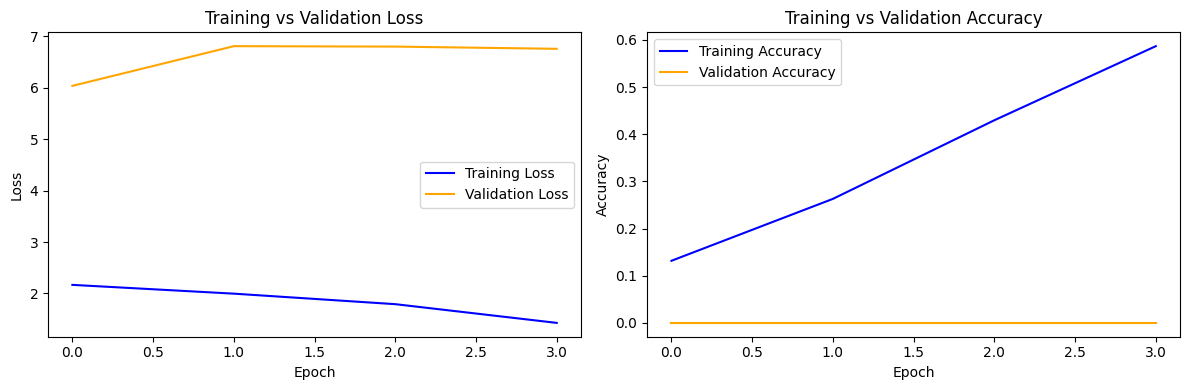

In [5]:
# Evaluate on test set (completely unseen data)
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"\n=== TEST RESULTS ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# === WHAT DO THESE NUMBERS MEAN? ===
# Test Loss: Lower is better (0 = perfect)
# Test Accuracy: Higher is better (1.0 = 100% correct)
# Good accuracy for digit classification: 95%+

# ---- VISUALIZE TRAINING PROGRESS ----
plt.figure(figsize=(12, 4))

# Plot 1: Loss over time
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Plot 2: Accuracy over time
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# === INTERPRETING THESE GRAPHS ===
# Good training: Both lines go down (loss) and up (accuracy)
# Overfitting: Training is great but validation gets worse
# Underfitting: Both are bad, need more training or better model

In [6]:
# ---- SAVE THE MODEL ----
# Saves architecture, weights, training config - EVERYTHING
model.save('devnagari_digit_model.h5')
print("Model saved as 'devnagari_digit_model.h5'")

# ---- LOAD THE MODEL ----
# In a new session or script, you can load like this:
loaded_model = tf.keras.models.load_model('devnagari_digit_model.h5')
print("Model loaded successfully!")

# Verify loaded model works
loss, accuracy = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model accuracy: {accuracy:.4f}")

Model saved as 'devnagari_digit_model.h5'
Model loaded successfully!
Loaded model accuracy: 0.2484


532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


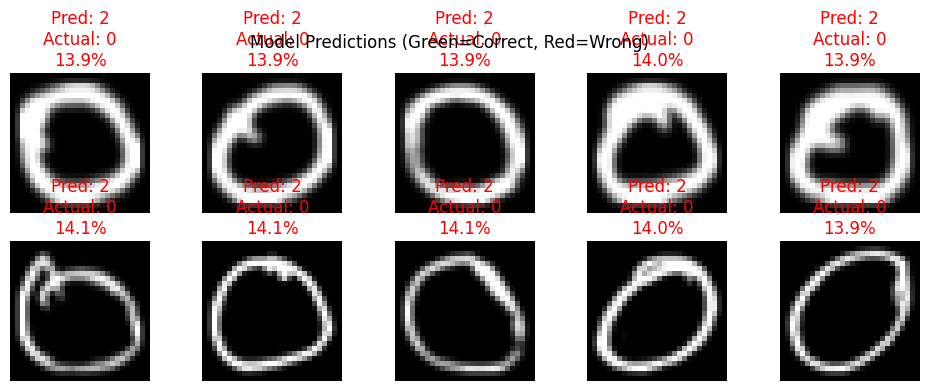

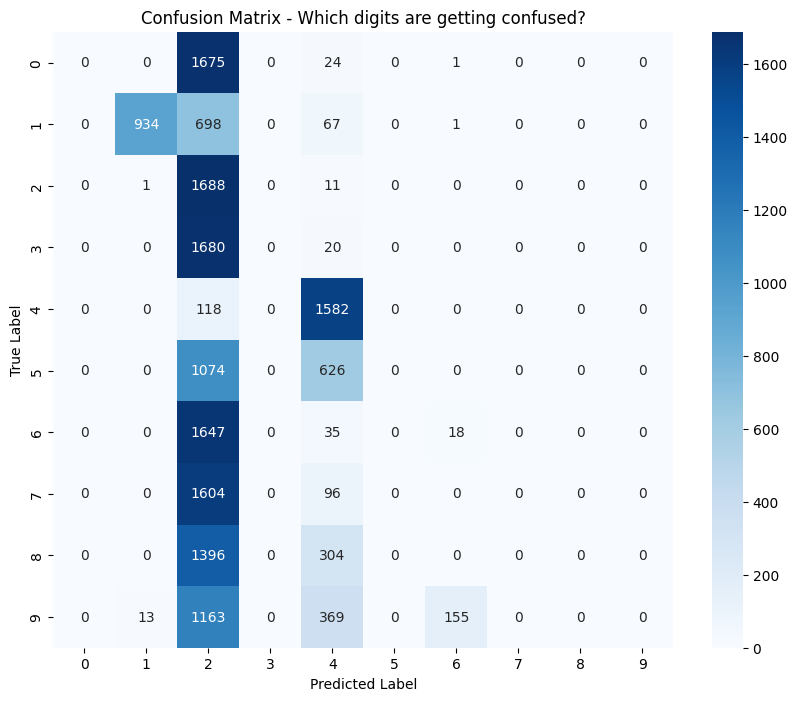

In [7]:
# ---- PREDICT ON TEST IMAGES ----
# Get probability distribution for each test image
predictions = loaded_model.predict(x_test)

# predictions shape: (num_test_images, 10)
# Each row has 10 probabilities that sum to 1.0

# Convert probabilities to actual digit predictions
predicted_digits = np.argmax(predictions, axis=1)  # axis=1 means across classes
true_digits = np.argmax(y_test, axis=1)

# ---- DISPLAY SOME PREDICTIONS ----
num_samples = 10
plt.figure(figsize=(12, 4))

for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    pred = predicted_digits[i]
    actual = true_digits[i]
    confidence = predictions[i][pred] * 100

    color = 'green' if pred == actual else 'red'
    plt.title(f"Pred: {pred}\nActual: {actual}\n{confidence:.1f}%", color=color)
    plt.axis('off')

plt.suptitle("Model Predictions (Green=Correct, Red=Wrong)")
plt.show()

# ---- CALCULATE CONFUSION MATRIX (optional) ----
# Shows WHICH digits the model confuses
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_digits, predicted_digits)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Which digits are getting confused?')
plt.show()

# If you see high numbers off-diagonal, the model confuses those digits
# Example: High value at (4,9) means it often predicts '9' when it's '4'